In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score


# Classification du poste à partir du profil de jeu (régression logistique)



## 0. Imports et chargement

In [ ]:

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7, 6)

players = pd.read_csv('../data/players_clean.csv')
print("Table joueur :", players.shape)


Table joueur : (1248, 60)


## 1. Sélection des variables 

Pour garder le modèle lisible et interprétable, on se limite à **12 statistiques de jeu
brutes**, couvrant les dimensions offensive, défensive et de passe. On exclut volontairement



In [2]:
feature_cols = [
    'goals', 'assists', 'shots', 'tackles', 'interceptions',
    'clearances', 'successful_passes', 'pass_accuracy',
    'aerial_duels_won', 'dribbles_attempted', 'defensive_actions', 'crosses',
]

X = players[feature_cols].copy()
y = players['position'].copy()

print("Nombre de variables explicatives :", len(feature_cols))
print()
print("Répartition des postes (variable à prédire) :")
print(y.value_counts())


Nombre de variables explicatives : 12

Répartition des postes (variable à prédire) :
position
Defender      432
Midfielder    384
Forward       288
Goalkeeper    144
Name: count, dtype: int64


**Point de vigilance** : les classes ne sont pas équilibrées (432 défenseurs contre 144
gardiens). On utilise `class_weight='balanced'` dans le modèle pour ne pas pénaliser les postes
les moins représentés.

**Standardisation** : contrairement à un arbre de décision, la régression logistique est
sensible à l'échelle des variables (un but et un nombre de passes n'ont pas la même échelle).
On standardise donc chaque variable (moyenne 0, écart-type 1) avant l'entraînement.


## 2. Séparation train / test et standardisation


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Échantillon d'entraînement :", X_train.shape[0], "joueurs")
print("Échantillon de test        :", X_test.shape[0], "joueurs")


Échantillon d'entraînement : 936 joueurs
Échantillon de test        : 312 joueurs


## 3. Entraînement du modèle


In [4]:
model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42,
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Précision globale (accuracy) sur l'échantillon de test : {acc:.1%}")


Précision globale (accuracy) sur l'échantillon de test : 100.0%


## 4. Test de robustesse : sans les gardiens


In [5]:
outfield = players[players['position'] != 'Goalkeeper']
X_of = outfield[feature_cols]
y_of = outfield['position']

X_of_train, X_of_test, y_of_train, y_of_test = train_test_split(
    X_of, y_of, test_size=0.25, random_state=42, stratify=y_of
)

scaler_of = StandardScaler()
X_of_train_s = scaler_of.fit_transform(X_of_train)
X_of_test_s = scaler_of.transform(X_of_test)

model_of = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
model_of.fit(X_of_train_s, y_of_train)
pred_of = model_of.predict(X_of_test_s)

acc_of = accuracy_score(y_of_test, pred_of)
print(f"Précision (défenseurs / milieux / attaquants uniquement) : {acc_of:.1%}")


Précision (défenseurs / milieux / attaquants uniquement) : 100.0%


## 5. Résultats détaillés par poste (modèle complet)


In [6]:
print(classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

    Defender      1.000     1.000     1.000       108
     Forward      1.000     1.000     1.000        72
  Goalkeeper      1.000     1.000     1.000        36
  Midfielder      1.000     1.000     1.000        96

    accuracy                          1.000       312
   macro avg      1.000     1.000     1.000       312
weighted avg      1.000     1.000     1.000       312



## 6. Matrice de confusion


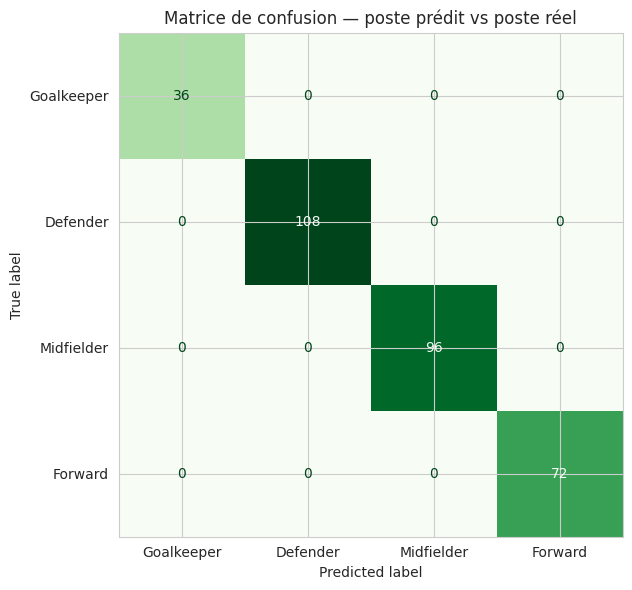

In [7]:
order = ['Goalkeeper', 'Defender', 'Midfielder', 'Forward']
cm = confusion_matrix(y_test, y_pred, labels=order)

fig, ax = plt.subplots(figsize=(6.5, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=order)
disp.plot(ax=ax, cmap='Greens', colorbar=False, values_format='d')
ax.set_title("Matrice de confusion — poste prédit vs poste réel")
plt.tight_layout()
plt.show()


## 7. Interprétation des coefficients

In [8]:
coef_df = pd.DataFrame(model.coef_, index=model.classes_, columns=feature_cols)
coef_df.round(2)


,goals,assists,shots,tackles,interceptions,clearances,successful_passes,pass_accuracy,aerial_duels_won,dribbles_attempted,defensive_actions,crosses
Defender,-0.36,-0.23,-0.43,0.76,0.66,1.67,0.20,-0.13,0.52,-1.06,1.20,-0.04
Forward,1.00,0.26,1.50,-0.22,-0.65,-0.69,-0.91,-0.09,-0.01,1.13,-0.52,-0.87
Goalkeeper,-0.68,-0.38,-1.08,-0.86,-0.24,0.16,-0.09,-1.71,-0.05,-0.76,-0.33,-0.28
Midfielder,0.03,0.35,0.01,0.32,0.23,-1.15,0.80,1.93,-0.47,0.69,-0.36,1.18


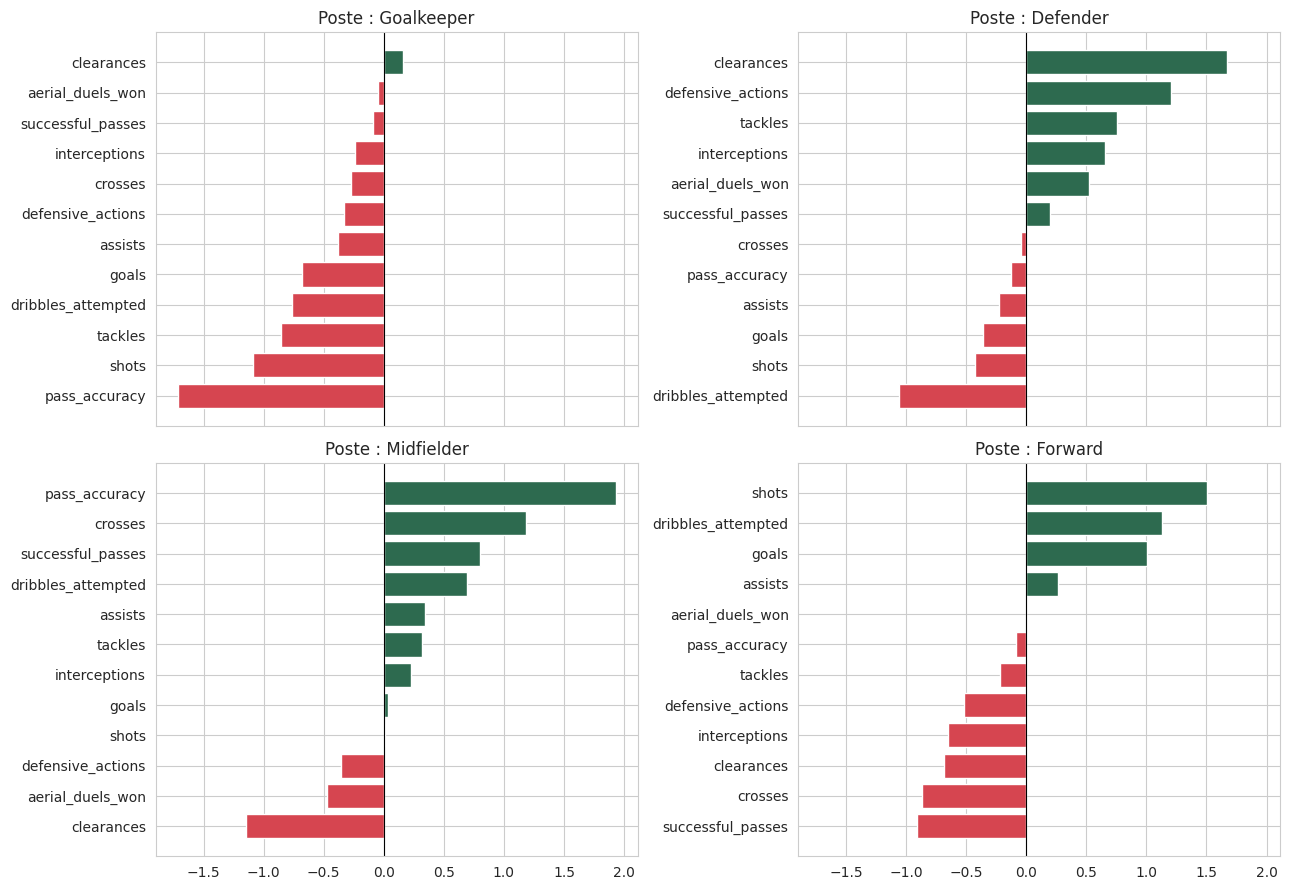

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
axes = axes.flatten()

for ax, pos in zip(axes, order):
    row = coef_df.loc[pos].sort_values()
    colors = ['#D64550' if v < 0 else '#2D6A4F' for v in row.values]
    ax.barh(row.index, row.values, color=colors)
    ax.set_title(f"Poste : {pos}")
    ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()
